In [3]:
import os
import re

# ---------------------------------------------------------
# STEP 1: CONFIGURATION
# ---------------------------------------------------------
# Path to the directory containing the log files
# Use the variable appropriate for your test case
empty_blocks = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_17-35-00_to_2026-01-15_17-50-00/'
test_490_txs = '/home/christos/shielded/jupyter/2026-01-14/all_logs/'
new_100_txs = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_21-30-50_to_2026-01-15_21-34-35/'
new_200_txs = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_21-38-08_to_2026-01-15_21-44-01/'

# Set active log directory here
log_dir = test_490_txs

BLOCK_PRODUCERS = [
    "alice", "bob", "charlie", "dave", "eve", "kate", "leo", "mike", "nina", "oliver",
    "ferdie", "george", "henry", "iris", "jack", "paul", "quinn", "rita", "sam", "tom"
]

# ---------------------------------------------------------
# STEP 2: DEFINE PARSING LOGIC
# ---------------------------------------------------------

def count_validated_transactions(log_directory, nodes):
    """
    Reads log files and counts unique 'Validated Midnight transaction' entries
    using regex. Returns a set of all unique TXs and a dict of counts per node.
    """
    total_unique_txs = set()
    node_stats = {}
    files_processed = 0

    # Regex matches: Validated Midnight transaction "618804..."
    tx_pattern = re.compile(r'Validated Midnight transaction "([a-fA-F0-9]+)"')

    print(f"Scanning logs in: {log_directory}\n")

    for node in nodes:
        file_path = os.path.join(log_directory, f"{node}.txt")
        node_unique_txs = set()
        
        if not os.path.exists(file_path):
            # If file doesn't exist, we just record 0 for this node
            node_stats[node] = 0
            # print(f"⚠️ Log file not found for: {node}") # Optional warning
            continue

        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    match = tx_pattern.search(line)
                    if match:
                        tx_hash = match.group(1)
                        node_unique_txs.add(tx_hash)
            
            # Update stats
            node_stats[node] = len(node_unique_txs)
            total_unique_txs.update(node_unique_txs)
            files_processed += 1
            
        except Exception as e:
            print(f"Error reading file for {node}: {e}")
            node_stats[node] = 0

    return total_unique_txs, node_stats, files_processed

# ---------------------------------------------------------
# STEP 3: RUN ANALYSIS
# ---------------------------------------------------------

unique_tx_set, node_counts, files_count = count_validated_transactions(log_dir, BLOCK_PRODUCERS)

# Print per-node statistics
for node in BLOCK_PRODUCERS:
    count = node_counts.get(node, 0)
    print(f"{node}: {count} distinct Validated transactions")

print("\n" + "=" * 50)
print(f"TOTAL DISTINCT TRANSACTIONS ACROSS ALL NODES: {len(unique_tx_set)}")
print("=" * 50)

Scanning logs in: /home/christos/shielded/jupyter/2026-01-14/all_logs/

alice: 490 distinct Validated transactions
bob: 490 distinct Validated transactions
charlie: 490 distinct Validated transactions
dave: 490 distinct Validated transactions
eve: 490 distinct Validated transactions
kate: 490 distinct Validated transactions
leo: 490 distinct Validated transactions
mike: 490 distinct Validated transactions
nina: 490 distinct Validated transactions
oliver: 490 distinct Validated transactions
ferdie: 490 distinct Validated transactions
george: 490 distinct Validated transactions
henry: 490 distinct Validated transactions
iris: 490 distinct Validated transactions
jack: 490 distinct Validated transactions
paul: 490 distinct Validated transactions
quinn: 490 distinct Validated transactions
rita: 490 distinct Validated transactions
sam: 490 distinct Validated transactions
tom: 490 distinct Validated transactions

TOTAL DISTINCT TRANSACTIONS ACROSS ALL NODES: 490


Scanning for block creation events in: /home/christos/shielded/jupyter/2026-01-14/all_logs/
Found 61 blocks. Plotting...
Graph saved as 'block_creation_timeline.png'


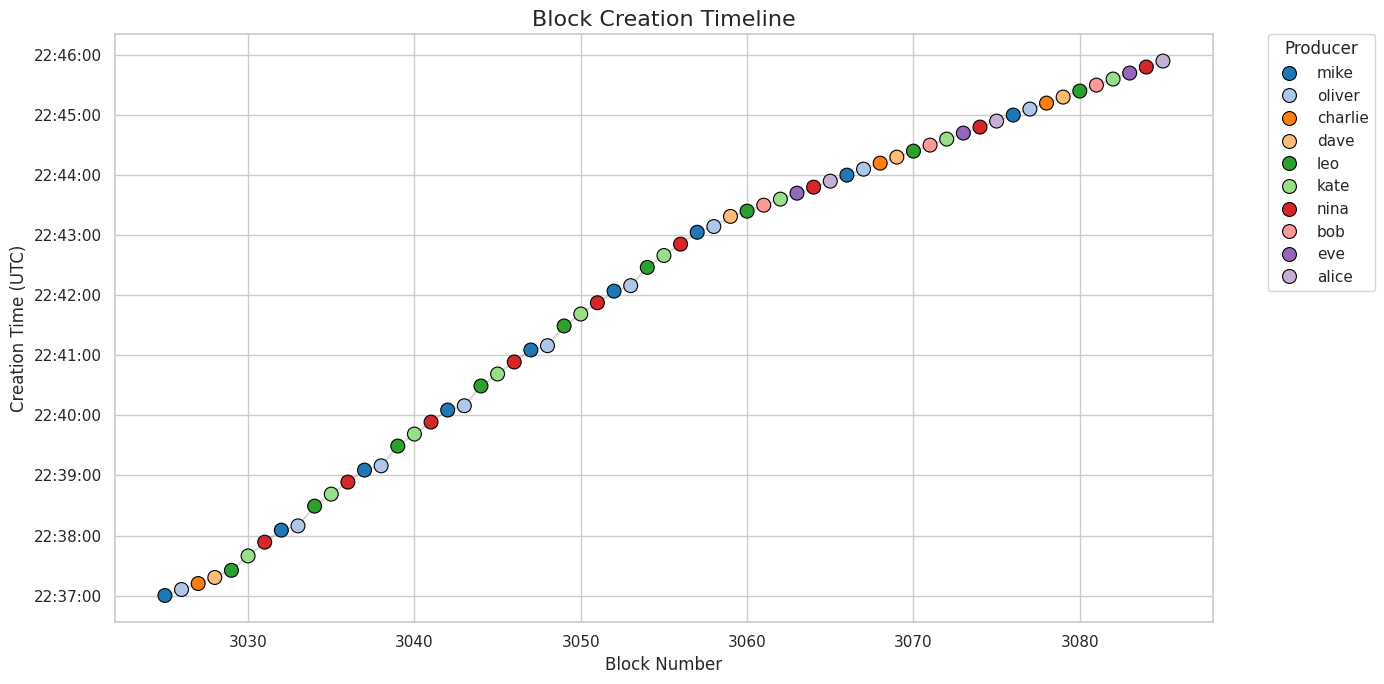

In [4]:
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from datetime import datetime

# ---------------------------------------------------------
# STEP 4: PARSE BLOCK CREATION TIMES (Re-parsing for Timeline)
# ---------------------------------------------------------
# We need to scan the logs again specifically for block creation events 
# to build the creation_registry required for the plot.

creation_registry = {} 

# Regex to capture timestamp and creation event
timestamp_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+)")
creation_pattern = re.compile(r"Pre-sealed block for proposal at (\d+)")

print(f"Scanning for block creation events in: {log_dir}")

for node in BLOCK_PRODUCERS:
    filepath = os.path.join(log_dir, f"{node}.txt")
    
    if not os.path.exists(filepath):
        continue
        
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            
            # Check for creation line first (optimization)
            create_match = creation_pattern.search(line)
            if create_match:
                # Extract Timestamp
                ts_match = timestamp_pattern.search(line)
                if not ts_match: continue
                
                try:
                    ts_str = ts_match.group(1)
                    if len(ts_str.split('.')[-1]) > 6: ts_str = ts_str[:26]
                    current_time = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                    
                    block_num = int(create_match.group(1))
                    
                    # Store data
                    creation_registry[block_num] = {
                        'time': current_time,
                        'creator': node
                    }
                except ValueError:
                    continue

# ---------------------------------------------------------
# STEP 5: PLOT BLOCK CREATION TIMELINE
# ---------------------------------------------------------

if not creation_registry:
    print("No block creation events found. Check log path.")
else:
    # Convert registry to DataFrame
    creation_data = []
    for block_num, info in creation_registry.items():
        creation_data.append({
            "Block": block_num,
            "Timestamp": info['time'],
            "Creator": info['creator']
        })

    df_creation = pd.DataFrame(creation_data).sort_values("Block")

    print(f"Found {len(df_creation)} blocks. Plotting...")

    # Setup the Plot
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # 1. Draw a line to show the progression
    sns.lineplot(
        data=df_creation,
        x="Block",
        y="Timestamp",
        color="gray",
        alpha=0.3,
        zorder=1
    )

    # 2. Draw points colored by the Creator Node
    plot = sns.scatterplot(
        data=df_creation,
        x="Block",
        y="Timestamp",
        hue="Creator",
        palette="tab20",  # Colorful palette for many nodes
        s=100,            # Dot size
        edgecolor="black",
        zorder=2
    )

    # Format Y-Axis to show HH:MM:SS
    plot.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

    plt.title("Block Creation Timeline", fontsize=16)
    plt.xlabel("Block Number", fontsize=12)
    plt.ylabel("Creation Time (UTC)", fontsize=12)

    # Ensure integer ticks on X-axis if valid range
    if df_creation["Block"].nunique() < 20:
        plt.xticks(df_creation["Block"].unique())

    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Producer")
    
    plt.tight_layout()
    plt.savefig("block_creation_timeline.png", dpi=300)
    print("Graph saved as 'block_creation_timeline.png'")
    
    plt.show()